# Tutorial 07 — Agrupamento, grafos e componentes reais

**Resoluções comentadas em português.** Material de estudo preparado com assistência de IA a partir de MM845 (Edward Hirst e Tomás S. R. Silva). Não é um gabarito oficial, nem um relato de execução no computador pessoal de Nina.

Os enunciados originais são preservados antes de cada solução. As saídas desta cópia são produzidas pela execução das células; os parâmetros e as sementes estão explícitos. As conclusões empíricas valem para esses experimentos, não como teoremas gerais.

[Mini-relatório](README.md) · [Material original](../../material_original/)

In [1]:
from pathlib import Path
import sys, os
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "estudos" / "comum.py").exists()), None)
if ROOT is None: raise RuntimeError("Abra este notebook dentro da pasta MM845-resolvido.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from estudos.comum import *
from IPython.display import display, Markdown
rng = np.random.default_rng(SEED + 7)
torch.manual_seed(SEED + 7)
OUT = ROOT / "estudos" / "tutorial_07" / "resultados"
OUT.mkdir(parents=True, exist_ok=True)
print("Semente:", SEED + 7, "| CPU | NumPy:", np.__version__, "| PyTorch:", torch.__version__)

Semente: 20260915 | CPU | NumPy: 2.3.5 | PyTorch: 2.10.0+cpu


## A referência geométrica e as limitações da amostra

Para a curva afim real $y^2=x^3+px+q$, o cúbico tem três raízes reais simples quando $4p^3+27q^2<0$; nesse caso há uma oval compacta e uma componente não compacta. Com uma única raiz simples real há uma componente. **Na igualdade a curva é singular**, e não devemos usar automaticamente a classificação do caso regular. Esses parâmetros são marcados separadamente.

A amostragem abaixo segue o caderno: rejeição uniforme em $x$, sinal de $y$ aleatório e ruído, em uma janela finita. Não é uniforme em comprimento de arco; tampouco é a curva completa. Corrigimos o contador da rotina original para contar pontos, não o número de blocos acumulados. Usamos ARI (*adjusted Rand index*) para comparar partições com a referência, sem o problema de nomes arbitrários das classes. O número de clusters exclui os pontos rotulados como ruído por DBSCAN.

**Outra precisão:** a célula de Voronoi é convexa, mas a interseção dela com uma nuvem não precisa formar um conjunto convexo. A restrição relevante são as fronteiras lineares entre células. Uma componente de grafo tem autovalor zero exato em aritmética exata; pequenas perturbações numéricas não transformam isso em um princípio de ausência de zeros.

In [2]:
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import adjusted_rand_score
from scipy.sparse.csgraph import connected_components, minimum_spanning_tree
centres=np.array([[0.,0.],[3.,.5],[1.4,2.8]])
y_blob=rng.integers(0,3,600);X_blob=centres[y_blob]+.42*rng.normal(size=(600,2))
y_circ=rng.integers(0,2,600);rad=np.where(y_circ==0,1.,2.4)+.10*rng.normal(size=600)
theta=rng.uniform(0,2*np.pi,600);X_circ=np.column_stack((rad*np.cos(theta),rad*np.sin(theta)))
X_ell=sample_elliptic(800,-3,1,rng,x_max=2.5)
roots=np.sort(np.roots([1,0,-3,1]).real)
y_ell=(X_ell[:,0]>(roots[1]+roots[2])/2).astype(int)

def spectrum(W,n_eig=None):
    W=W.toarray() if sparse.issparse(W) else np.asarray(W)
    d=W.sum(1);s=1/np.sqrt(np.maximum(d,1e-15))
    L=np.eye(len(W))-s[:,None]*W*s[None,:]
    return linalg.eigh(L,subset_by_index=None if n_eig is None else [0,n_eig-1],check_finite=False)

def db_count(X,eps):
    labels=DBSCAN(eps=eps,min_samples=4).fit_predict(X)
    return len(set(labels)-{-1}),float(np.mean(labels==-1)),labels

## Exercício 1

> **Exercise 1 — the geometry of $k$-means.**
> (a) The objective decreases monotonically but the result depends on
> initialisation. Run k-means on the blobs from 50 random seeds and histogram the
> final inertia. How often does it find the best solution, and does k-means++
> seeding help?
>
> (b) Plot inertia against $k$ for the blobs (the "elbow method"). Now do the same
> for the circles. What does the elbow tell you when the model is wrong?
>
> (c) Apply k-means to the elliptic curve with $k=2$. Does it recover the two real
> components? Explain the result from the Voronoi picture before you run it.

### Resolução

**(a) Inicialização.** Cada execução usa `n_init=1`: deixar o padrão executar vários reinícios mudaria a pergunta. Comparamos 50 sementes aleatórias e 50 sementes k-means++, registrando a fração que chega à menor inércia *observada*, com tolerância relativa $10^{-6}$. Não chamamos esse mínimo de ótimo global certificado. As alternâncias de Lloyd não aumentam o objetivo porque cada uma minimiza uma variável com a outra fixa; isso não torna o problema conjunto convexo. Em blobs bem separados, ambos podem acertar quase sempre, de modo que ausência de diferença não contradiz a utilidade geral da inicialização.

**(b) O cotovelo mede compressão por centros.** Nos três blobs, uma mudança de inclinação perto de três pode acompanhar os três grupos. Nos círculos, aumentar $k$ também reduz distorção, mas os centros passam a repartir ângulos/setores. O gráfico não diagnostica sozinho componentes topológicas. Com dois centros, a fronteira de atribuição é uma reta, que não consegue separar globalmente dois círculos concêntricos completos.

**(c) Predição antes da execução.** Na curva elíptica com três raízes, a oval ocupa $x\in[r_1,r_2]$ e a componente não compacta começa em $x=r_3$. Há, portanto, uma reta vertical que **pode** separar as componentes. Isso não obriga k-means a escolhê-la: sua função objetivo pode preferir dividir a componente longa em dois pedaços ou separar regiões superior/inferior. Plotamos a partição e a fronteira real entre os dois centros, e medimos ARI em vez de presumir sucesso ou fracasso.

inicializacao  semente    inercia  ARI
       random        0 206.182362  1.0
       random        1 206.182362  1.0
       random        2 206.182362  1.0
       random        3 206.182362  1.0
       random        4 206.182362  1.0
       random        5 206.182362  1.0
       random        6 206.182362  1.0
       random        7 206.182362  1.0
       random        8 206.182362  1.0
       random        9 206.182362  1.0
       random       10 206.182362  1.0
       random       11 206.182362  1.0
       random       12 206.182362  1.0
       random       13 206.182362  1.0
       random       14 206.182362  1.0
          ...      ...        ...  ...
    k-means++       35 206.182362  1.0
    k-means++       36 206.182362  1.0
    k-means++       37 206.182362  1.0
    k-means++       38 206.182362  1.0
    k-means++       39 206.182362  1.0
    k-means++       40 206.182362  1.0
    k-means++       41 206.182362  1.0
    k-means++       42 206.182362  1.0
    k-means++       43 20

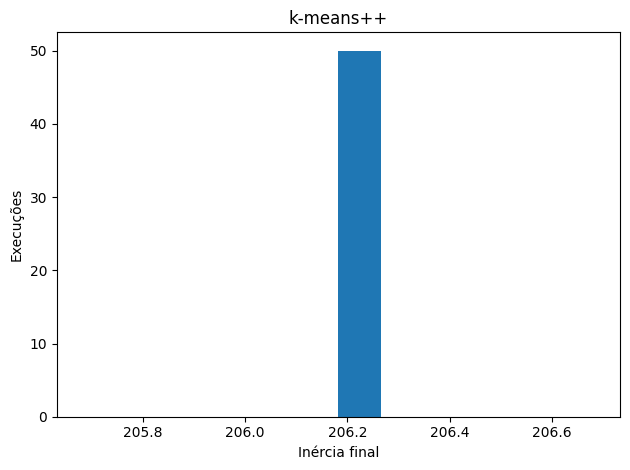

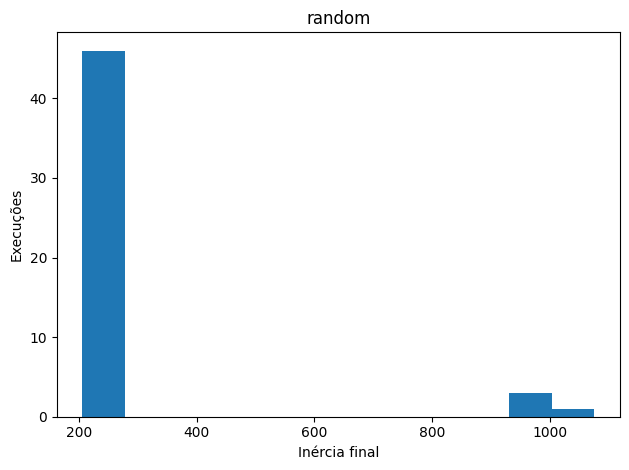

inicializacao  fracao_melhor_observado
    k-means++                     1.00
       random                     0.92


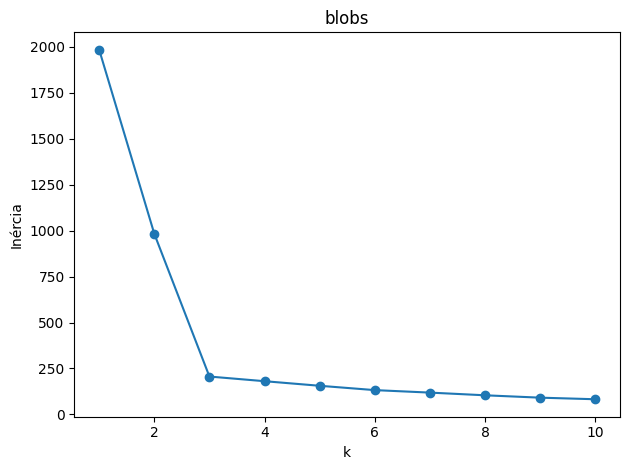

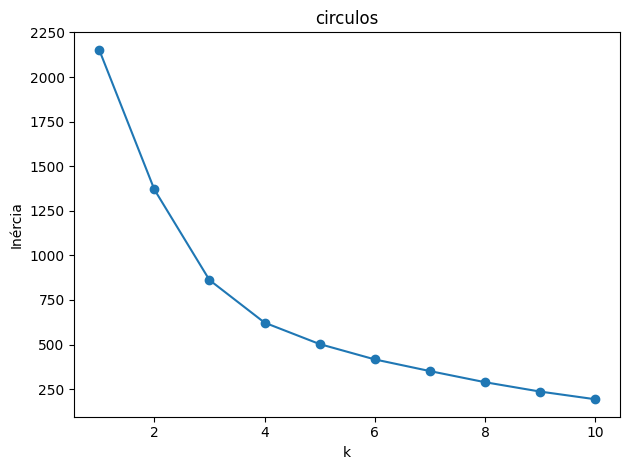

   dados  k     inercia       ARI
   blobs  1 1984.547762  0.000000
   blobs  2  982.968298  0.580229
   blobs  3  206.182362  1.000000
   blobs  4  180.861030  0.862254
   blobs  5  155.935475  0.718977
   blobs  6  132.336238  0.572491
   blobs  7  118.786000  0.514294
   blobs  8  104.156512  0.460766
   blobs  9   91.281731  0.400435
   blobs 10   82.608930  0.367750
circulos  1 2152.936630  0.000000
circulos  2 1369.925004 -0.001652
circulos  3  862.116425 -0.001139
circulos  4  623.027759  0.001248
circulos  5  502.771032  0.005450
circulos  6  416.813632  0.130027
circulos  7  351.381523  0.236267
circulos  8  288.959085  0.236305
circulos  9  236.464360  0.234007
circulos 10  193.366884  0.218635
Curva elíptica: ARI = 0.002062945484451077 | raízes: [-1.87938524  0.34729636  1.53208889]


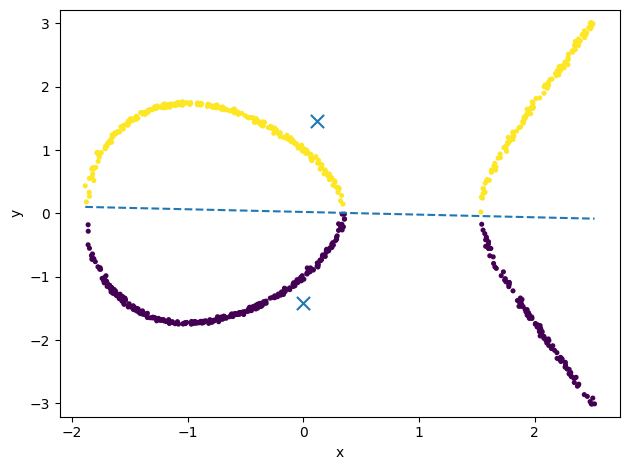

In [3]:
inertias=[]
for init in ['random','k-means++']:
    for seed in range(50):
        km=KMeans(n_clusters=3,init=init,n_init=1,max_iter=300,random_state=seed).fit(X_blob)
        inertias.append(dict(inicializacao=init,semente=seed,inercia=km.inertia_,ARI=adjusted_rand_score(y_blob,km.labels_)))
inertias=table(inertias,'kmeans_50_sementes',OUT)
best=inertias.inercia.min();success=[]
for name,df in inertias.groupby('inicializacao'):
    success.append(dict(inicializacao=name,fracao_melhor_observado=np.mean(np.isclose(df.inercia,best,rtol=1e-6))))
    plt.figure();plt.hist(df.inercia,bins=12);plt.xlabel('Inércia final');plt.ylabel('Execuções');plt.title(name);figure('inercia_'+name.replace('+','p'),OUT)
success=table(success,'frequencia_melhor_kmeans',OUT)
elbows=[]
for name,X,y in [('blobs',X_blob,y_blob),('circulos',X_circ,y_circ)]:
    for k in range(1,11):
        km=KMeans(n_clusters=k,n_init=10,random_state=17).fit(X)
        elbows.append(dict(dados=name,k=k,inercia=km.inertia_,ARI=adjusted_rand_score(y,km.labels_)))
    df=pd.DataFrame(elbows).query('dados==@name')
    plt.figure();plt.plot(df.k,df.inercia,marker='o');plt.xlabel('k');plt.ylabel('Inércia');plt.title(name);figure('cotovelo_'+name,OUT)
elbows=table(elbows,'cotovelos_e_ARI',OUT)
km=KMeans(n_clusters=2,n_init=20,random_state=17).fit(X_ell)
print('Curva elíptica: ARI =',adjusted_rand_score(y_ell,km.labels_),'| raízes:',roots)
plt.figure();plt.scatter(*X_ell.T,c=km.labels_,s=7);plt.scatter(*km.cluster_centers_.T,marker='x',s=90)
C=km.cluster_centers_;normal=C[1]-C[0];offset=(np.dot(C[1],C[1])-np.dot(C[0],C[0]))/2
if abs(normal[1])>1e-8:
    xx=np.array([X_ell[:,0].min(),X_ell[:,0].max()]);plt.plot(xx,(offset-normal[0]*xx)/normal[1],linestyle='--')
else:plt.axvline(offset/normal[0],linestyle='--')
plt.ylim(X_ell[:,1].min()-.2,X_ell[:,1].max()+.2);plt.xlabel('x');plt.ylabel('y');figure('voronoi_eliptica',OUT)

## Exercício 2

> **Exercise 2 — the graph is the model.**
> (a) Sweep $k$ in the $k$-NN graph from 3 to 40 on the concentric circles and plot
> the number of near-zero eigenvalues. For which $k$ do the two circles merge into
> one component, and can you predict that value from the gap between the circles and
> the sampling density?
>
> (b) Replace the $k$-NN graph by a Gaussian kernel $W_{ij} = e^{-\lVert x_i-x_j\rVert^2/2t}$
> and sweep $t$. Which parametrisation is more robust here?
>
> (c) The **Fiedler vector** (the eigenvector of the smallest non-zero eigenvalue)
> gives a bipartition even when the graph is connected. Plot it as a colour on the
> elliptic curve for a case with only *one* real component. What does it split, and
> is the split geometrically meaningful?

### Resolução

**(a) O grafo muda com $k$.** Para um grafo simétrico com pesos não negativos e graus positivos, $\dim\ker L$ é o número de componentes. Registramos tanto a contagem combinatória exata quanto a contagem numérica de autovalores menores que $10^{-8}$. Um primeiro limite para a fusão é o menor rank de qualquer vizinho pertencente ao outro círculo: quando $k$ alcança esse rank, aparece a primeira aresta interclasse. Se cada círculo já estiver internamente conectado, essa aresta funde os dois.

Para círculos ideais, uma corda de comprimento $\delta$ em raio $r$ corresponde a abertura $2\arcsin(\delta/(2r))$ para cada lado. Assim, aproximadamente $n_r\,2\arcsin(\delta/(2r))/\pi$ vizinhos do mesmo círculo cabem antes da lacuna radial $\delta$. Ruído e flutuação de densidade podem antecipar a primeira ponte. Não é obrigatório que ela apareça em $3\le k\le40$; calculamos o rank observado e, quando necessário, estendemos a tabela para além de 40.

**(b) Gaussiano não truncado.** Para qualquer $t>0$, todos os pesos entre pontos distintos são estritamente positivos em aritmética real: o grafo completo tem **uma** componente. Dois autovalores quase zero indicam conexão fraca, não desconexão literal. Subfluxo de ponto flutuante e limiares numéricos mudam isso na implementação. Comparar robustez exige dizer o critério: mostramos faixa de parâmetros com ARI alto para uma bipartição espectral e a contagem de modos abaixo de um limiar fixo. Não comparamos diretamente os comprimentos de faixas em unidades incomensuráveis de $k$ e $t$.

**(c) Fiedler não é contador de componentes.** Em um grafo conectado, o menor autovalor positivo fornece a relaxação de uma separação de baixa energia. Pode separar duas regiões distantes, as partes superior/inferior da curva ou um estreitamento, mesmo quando $b_0=1$. Escolhemos $q=2.6$, conectamos o grafo e exibimos o vetor e a bipartição por sinal. O corte é uma descrição de conectividade/densidade amostral, não a descoberta de uma componente inexistente.

Primeiro rank de vizinho interclasse: 27


 k  componentes_exatas  modos_abaixo_1e8       lambda2       ARI
 3                  15                15 -1.744896e-15 -0.002492
 4                   5                 5 -9.549247e-16  0.470078
 5                   3                 3 -4.444047e-16  1.000000
 6                   2                 2  1.316740e-15  1.000000
 7                   2                 2  8.540004e-17  1.000000
 8                   2                 2 -1.900709e-17  1.000000
 9                   2                 2 -1.125441e-16  1.000000
10                   2                 2 -1.395840e-16  1.000000
11                   2                 2 -1.128895e-16  1.000000
12                   2                 2  1.413230e-15  1.000000
13                   2                 2  1.886541e-16  1.000000
14                   2                 2  1.349643e-16  1.000000
15                   2                 2  2.390611e-16  1.000000
16                   2                 2  2.661067e-17  1.000000
17                   2   

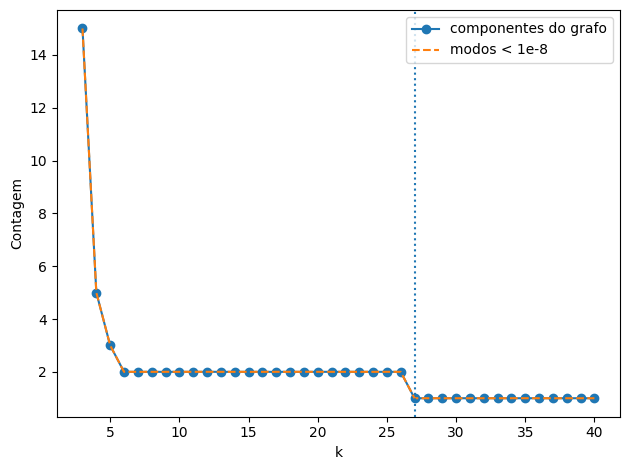

Estimativa ideal de vizinhos antes da lacuna, raio 1 : 134.7619121357773
Estimativa ideal de vizinhos antes da lacuna, raio 2.4 : 61.613206656681726


        t  modos_abaixo_1e6       lambda2       ARI
 0.001000                22 -1.471031e-16  1.000000
 0.001778                10  4.159365e-16  1.000000
 0.003162                 2  1.107107e-16  1.000000
 0.005623                 2 -2.984920e-17  1.000000
 0.010000                 2  9.820332e-18  1.000000
 0.017783                 2  4.182205e-12  1.000000
 0.031623                 2  2.913476e-08  1.000000
 0.056234                 1  8.190161e-06  1.000000
 0.100000                 1  5.977966e-04  1.000000
 0.177828                 1  1.346928e-02  1.000000
 0.316228                 1  6.801763e-02  0.016041
 0.562341                 1  1.610163e-01  0.000822
 1.000000                 1  2.819760e-01 -0.001385
 1.778279                 1  4.275117e-01 -0.001561
 3.162278                 1  5.857318e-01 -0.001561
 5.623413                 1  7.278719e-01 -0.001616
10.000000                 1  8.337487e-01 -0.001616


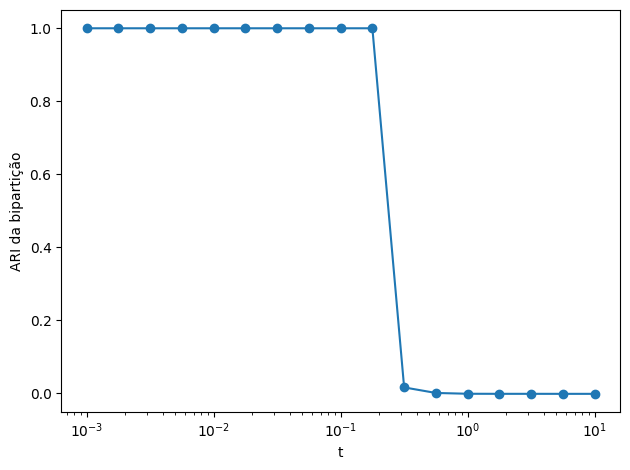

Valores testados com ARI > .95 — k: [5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40] | t: [0.001, 0.001778, 0.003162, 0.005623, 0.01, 0.017783, 0.031623, 0.056234, 0.1, 0.177828]
Curva com uma componente: k= 8 | lambda2= 4.6336049236093445e-05


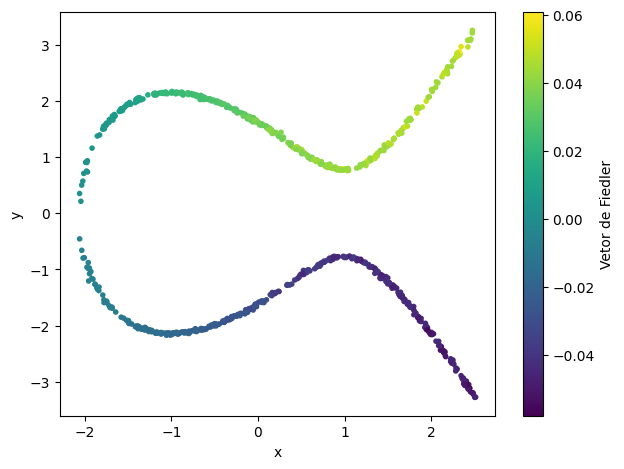

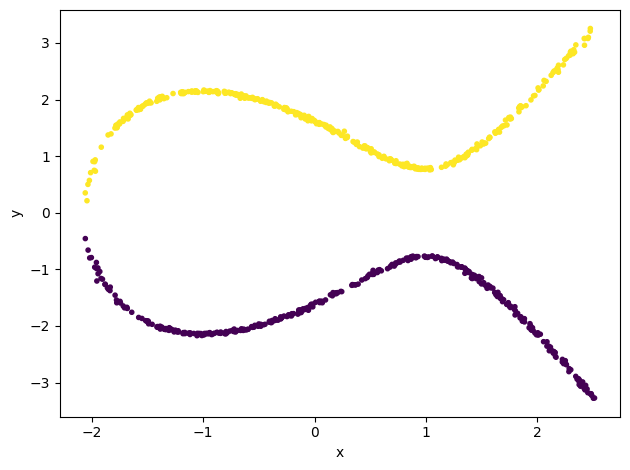

In [4]:
D=distance.squareform(distance.pdist(X_circ));order=np.argsort(D,axis=1)
first_cross=min(int(np.flatnonzero(y_circ[row]!=y_circ[i])[0]) for i,row in enumerate(order))
print('Primeiro rank de vizinho interclasse:',first_cross)
ks=sorted(set(range(3,41))|{first_cross,max(3,first_cross-1),first_cross+1})
graphrows=[]
for k in ks:
    W=knn_adjacency(X_circ,k);ncomp=connected_components(W,directed=False,return_labels=False)
    vals,V=spectrum(W)
    labels=KMeans(n_clusters=2,n_init=10,random_state=7).fit_predict(V[:,:2]/np.maximum(np.linalg.norm(V[:,:2],axis=1,keepdims=True),1e-15))
    graphrows.append(dict(k=k,componentes_exatas=ncomp,modos_abaixo_1e8=int((vals<1e-8).sum()),
                          lambda2=vals[1],ARI=adjusted_rand_score(y_circ,labels)))
graphrows=table(graphrows,'grafo_knn_varredura',OUT)
plt.figure();plt.plot(graphrows.k,graphrows.componentes_exatas,marker='o',label='componentes do grafo')
plt.plot(graphrows.k,graphrows.modos_abaixo_1e8,linestyle='--',label='modos < 1e-8');plt.axvline(first_cross,linestyle=':')
plt.xlabel('k');plt.ylabel('Contagem');plt.legend();figure('componentes_por_k',OUT)
for radius in [1,2.4]:
    nr=int((y_circ==(0 if radius==1 else 1)).sum())
    print('Estimativa ideal de vizinhos antes da lacuna, raio',radius,':',nr*2*np.arcsin(min(1,1.4/(2*radius)))/np.pi)

gaussian=[]
for t in np.logspace(-3,1,17):
    W=np.exp(-D**2/(2*t));np.fill_diagonal(W,0)
    vals,V=spectrum(W)
    emb=V[:,:2]/np.maximum(np.linalg.norm(V[:,:2],axis=1,keepdims=True),1e-15)
    labels=KMeans(n_clusters=2,n_init=10,random_state=7).fit_predict(emb)
    gaussian.append(dict(t=t,modos_abaixo_1e6=int((vals<1e-6).sum()),lambda2=vals[1],ARI=adjusted_rand_score(y_circ,labels)))
gaussian=table(gaussian,'grafo_gaussiano_varredura',OUT)
plt.figure();plt.semilogx(gaussian.t,gaussian.ARI,marker='o');plt.xlabel('t');plt.ylabel('ARI da bipartição');figure('robustez_gaussiano',OUT)
print('Valores testados com ARI > .95 — k:',graphrows.loc[graphrows.ARI>.95,'k'].tolist(),
      '| t:',gaussian.loc[gaussian.ARI>.95,'t'].round(6).tolist())

Xone=sample_elliptic(800,-3,2.6,rng)
for k in range(4,121,2):
    W=knn_adjacency(Xone,k)
    if connected_components(W,directed=False,return_labels=False)==1:break
assert connected_components(W,directed=False,return_labels=False)==1
vals,V=spectrum(W,6);fiedler=V[:,1]
print('Curva com uma componente: k=',k,'| lambda2=',vals[1])
plt.figure();plt.scatter(*Xone.T,c=fiedler,s=9);plt.colorbar(label='Vetor de Fiedler');plt.xlabel('x');plt.ylabel('y');figure('fiedler_uma_componente',OUT)
plt.figure();plt.scatter(*Xone.T,c=(fiedler>=0),s=9);plt.xlabel('x');plt.ylabel('y');figure('corte_fiedler',OUT)

## Exercício 3

> **Exercise 3 — how much did $\varepsilon$ decide?**
> (a) Redo the sweep for $\varepsilon \in \{0.3, 0.45, 0.6, 0.9\}$ and plot the
> recovered transition point against $\varepsilon$. How stable is the answer?
>
> (b) Persistent homology answers the same question without a scale choice, by
> tracking components across *all* $\varepsilon$ at once. Compute the number of
> $H_0$ bars that survive a long interval and compare. (This is Tutorial 11's
> subject; a rough version is a few lines with a minimum spanning tree.)
>
> (c) Sweep both $p$ and $q$ on a grid and colour the plane by the recovered
> component count. You should be drawing the discriminant curve
> $4p^3 + 27q^2 = 0$ — a cusp. How much sampling does it take to see the cusp
> clearly?

### Resolução

**(a) A escala decide parte da transição.** Para $p=-3$, o discriminante regular muda em $q=\pm2$. Reutilizamos a *mesma amostra para cada $q$* ao variar $\varepsilon$; assim, a diferença não vem de reamostrar os pontos entre escalas. Guardamos todas as contagens e todas as mudanças. Para uma estimativa automática sem escolher a mudança mais conveniente, partimos do platô de duas componentes que contém $q=0$ e procuramos a primeira saída à esquerda e à direita. Só chamamos a saída de transição $2\to1$ quando o valor externo é 1; fragmentação ou ausência do platô produzem estimativa ausente. A resolução em $q$ é 0.2, antes de qualquer incerteza amostral.

**(b) Persistência de $H_0$ pela árvore geradora mínima.** Na filtração de Vietoris–Rips em que uma aresta entra quando a distância é $\varepsilon$, todas as classes nascem em zero; os $N-1$ comprimentos das arestas da MST são os tempos de morte e sobra uma barra infinita. Portanto, a contagem sobrevivente na escala $\varepsilon$ é $1+\#\{\ell_{\mathrm{MST}}>\varepsilon\}$. Mostramos as barras mais longas e essa contagem. O cálculo percorre todas as escalas, mas chamar uma barra de “longa” **ainda exige um critério**. Distinguimos isso de DBSCAN, que também filtra por densidade e tem `min_samples=4`. Outliers e amostragem esparsa podem gerar barras longas que não são componentes da curva subjacente.

**(c) Cúspide e tamanho amostral.** Varremos $p,q$ em uma grade, com $N=300,1000,3000$, $\varepsilon=0.45$, ruído e janela fixos. A curva analítica é sobreposta apenas para avaliação. Registramos a fração de acertos fora dos pontos singulares e a fração de ruído. “Quantos pontos bastam” depende da distância à cúspide, da densidade, do ruído e do alcance geométrico: não existe um $N$ único garantido nesse protocolo. Mais pontos podem ajudar a conectar uma componente, mas também criar pontes de ruído entre componentes próximas com $\varepsilon$ fixo.

 epsilon    q  componentes  fracao_ruido  referencia
     0.3 -3.2            1           0.0         1.0
     0.3 -3.0            1           0.0         1.0
     0.3 -2.8            1           0.0         1.0
     0.3 -2.6            1           0.0         1.0
     0.3 -2.4            1           0.0         1.0
     0.3 -2.2            1           0.0         1.0
     0.3 -2.0            1           0.0         NaN
     0.3 -1.8            3           0.0         2.0
     0.3 -1.6            2           0.0         2.0
     0.3 -1.4            2           0.0         2.0
     0.3 -1.2            2           0.0         2.0
     0.3 -1.0            2           0.0         2.0
     0.3 -0.8            2           0.0         2.0
     0.3 -0.6            2           0.0         2.0
     0.3 -0.4            3           0.0         2.0
     ...  ...          ...           ...         ...
     0.9  0.4            2           0.0         2.0
     0.9  0.6            2           0.0      

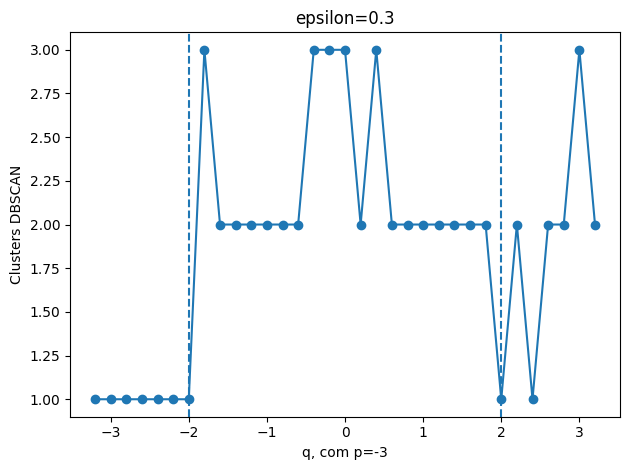

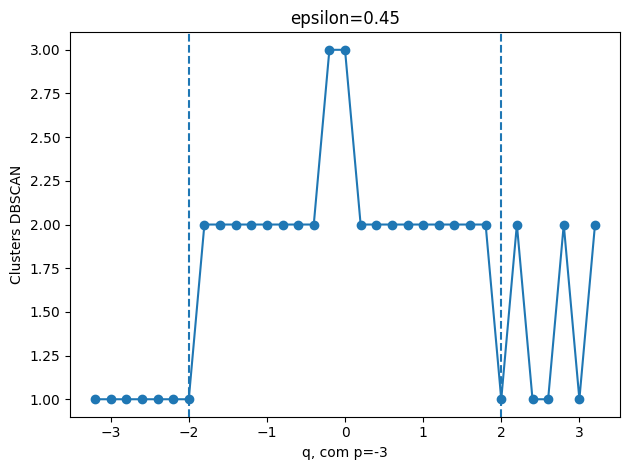

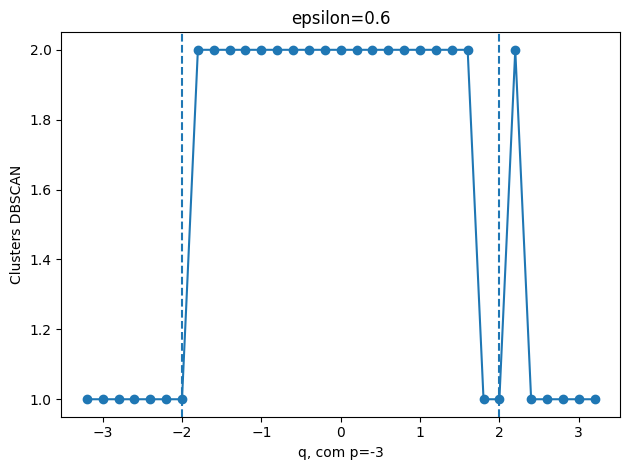

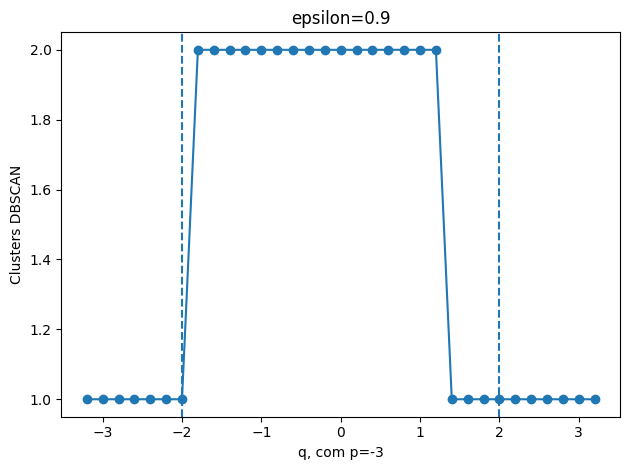

 epsilon   q0   q1  antes  depois
    0.30 -2.0 -1.8      1       3
    0.30 -1.8 -1.6      3       2
    0.30 -0.6 -0.4      2       3
    0.30  0.0  0.2      3       2
    0.30  0.2  0.4      2       3
    0.30  0.4  0.6      3       2
    0.30  1.8  2.0      2       1
    0.30  2.0  2.2      1       2
    0.30  2.2  2.4      2       1
    0.30  2.4  2.6      1       2
    0.30  2.8  3.0      2       3
    0.30  3.0  3.2      3       2
    0.45 -2.0 -1.8      1       2
    0.45 -0.4 -0.2      2       3
    0.45  0.0  0.2      3       2
    0.45  1.8  2.0      2       1
    0.45  2.0  2.2      1       2
    0.45  2.2  2.4      2       1
    0.45  2.6  2.8      1       2
    0.45  2.8  3.0      2       1
    0.45  3.0  3.2      1       2
    0.60 -2.0 -1.8      1       2
    0.60  1.6  1.8      2       1
    0.60  2.0  2.2      1       2
    0.60  2.2  2.4      2       1
    0.90 -2.0 -1.8      1       2
    0.90  1.2  1.4      2       1
 epsilon  q_esquerda  q_direita
    0.30        

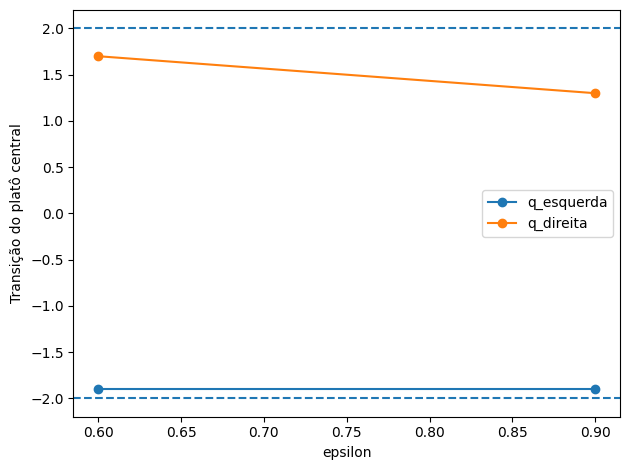

q= 0.0 | cinco mortes mais longas: [0.13541556 0.13667748 0.14979637 0.20211387 1.69434406]


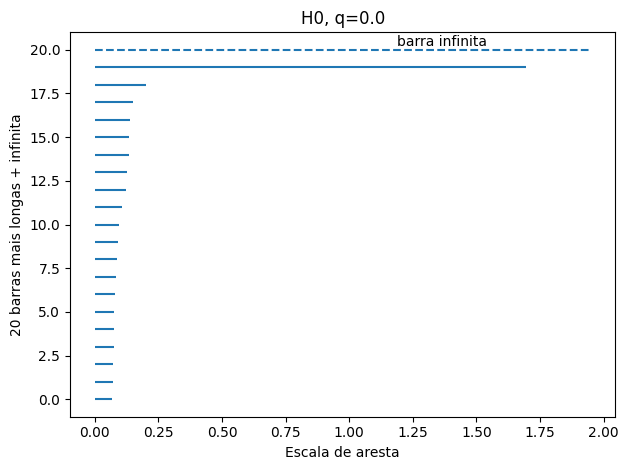

q= 1.8 | cinco mortes mais longas: [0.16075658 0.18998362 0.20193928 0.23396185 0.49608352]


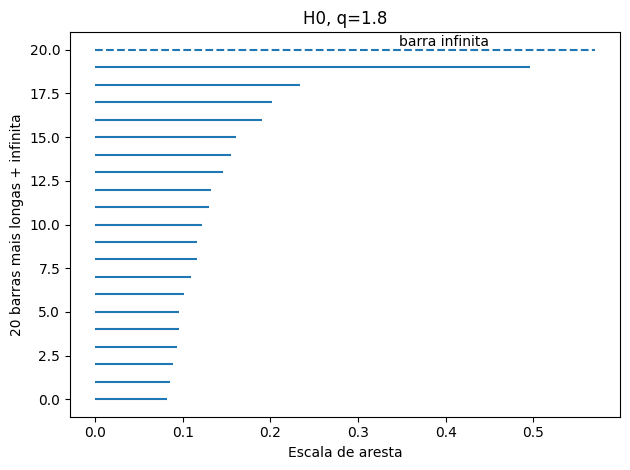

q= 2.2 | cinco mortes mais longas: [0.12156366 0.15510218 0.16677098 0.19179703 0.55978825]


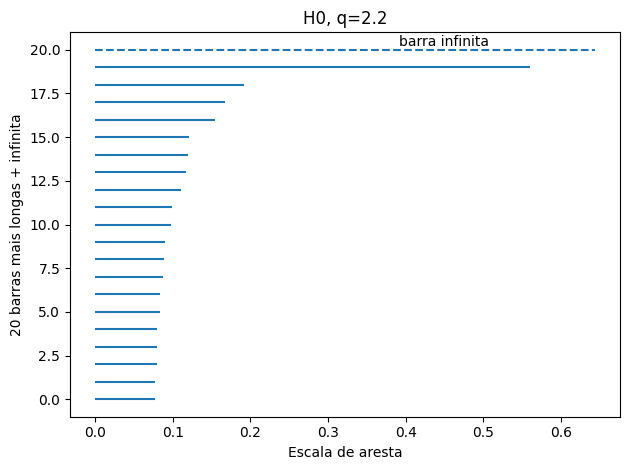

q= 3.0 | cinco mortes mais longas: [0.13495136 0.18738425 0.24454192 0.26085003 0.58767411]


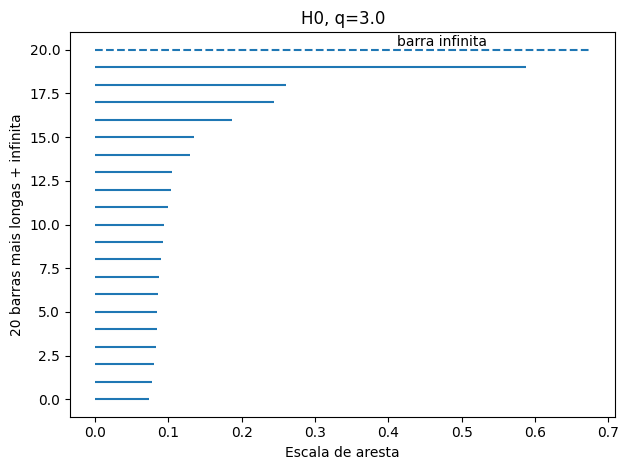

  q  epsilon  barras_H0_vivas  clusters_DBSCAN  referencia
0.0     0.30                2                2           2
0.0     0.45                2                2           2
0.0     0.60                2                2           2
0.0     0.90                2                2           2
1.8     0.30                2                2           2
1.8     0.45                2                2           2
1.8     0.60                1                1           2
1.8     0.90                1                1           2
2.2     0.30                2                2           1
2.2     0.45                2                2           1
2.2     0.60                1                1           1
2.2     0.90                1                1           1
3.0     0.30                2                2           1
3.0     0.45                2                2           1
3.0     0.60                1                1           1
3.0     0.90                1                1          

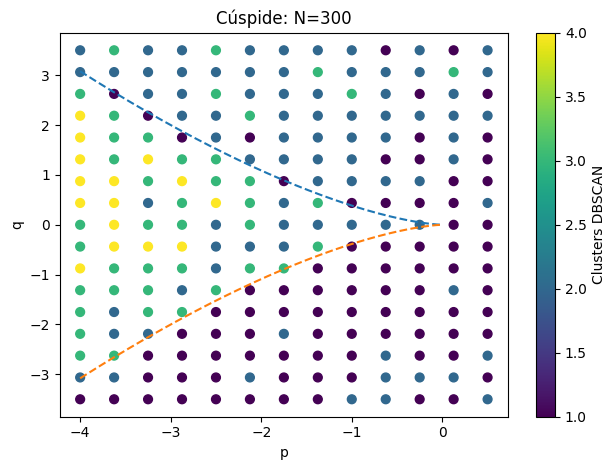

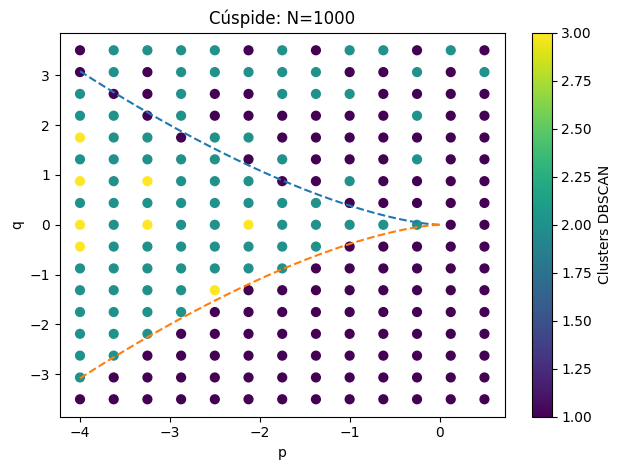

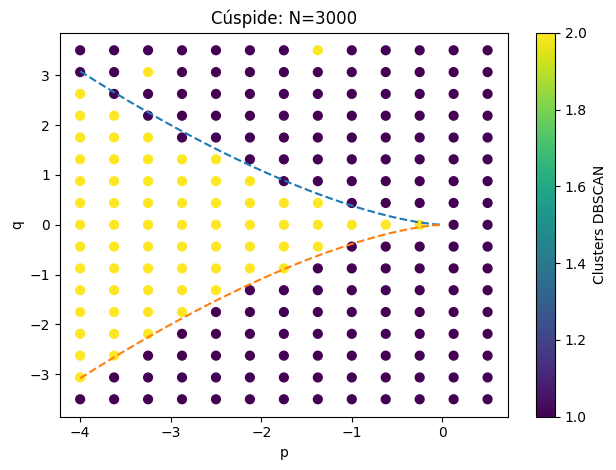

   N    p       q  componentes  fracao_ruido  referencia
 300 -4.0 -3.5000            1      0.000000           1
 300 -4.0 -3.0625            2      0.000000           2
 300 -4.0 -2.6250            3      0.000000           2
 300 -4.0 -2.1875            3      0.000000           2
 300 -4.0 -1.7500            3      0.000000           2
 300 -4.0 -1.3125            3      0.006667           2
 300 -4.0 -0.8750            4      0.000000           2
 300 -4.0 -0.4375            3      0.000000           2
 300 -4.0  0.0000            3      0.000000           2
 300 -4.0  0.4375            4      0.000000           2
 300 -4.0  0.8750            4      0.000000           2
 300 -4.0  1.3125            4      0.000000           2
 300 -4.0  1.7500            4      0.006667           2
 300 -4.0  2.1875            4      0.000000           2
 300 -4.0  2.6250            3      0.000000           2
 ...  ...     ...          ...           ...         ...
3000  0.5 -2.6250            1 

In [5]:
eps_values=[.3,.45,.6,.9];qs=np.linspace(-3.2,3.2,33)
clouds={float(q):sample_elliptic(1400,-3,float(q),rng) for q in qs}
scan=[]
for eps in eps_values:
    for q in qs:
        count,noise,_=db_count(clouds[float(q)],eps)
        scan.append(dict(epsilon=eps,q=q,componentes=count,fracao_ruido=noise,
                         referencia=exact_components(-3,float(q))))
scan=table(scan,'DBSCAN_transicao',OUT)
transitions=[];estimates=[]
for eps,df in scan.groupby('epsilon'):
    counts=df.componentes.to_numpy();qq=df.q.to_numpy();mid=int(np.argmin(abs(qq)))
    row=dict(epsilon=eps,q_esquerda=np.nan,q_direita=np.nan)
    for j in range(len(qq)-1):
        if counts[j]!=counts[j+1]:transitions.append(dict(epsilon=eps,q0=qq[j],q1=qq[j+1],antes=counts[j],depois=counts[j+1]))
    if counts[mid]==2:
        left=mid;right=mid
        while left>0 and counts[left-1]==2:left-=1
        while right<len(qq)-1 and counts[right+1]==2:right+=1
        if left>0 and counts[left-1]==1:row['q_esquerda']=(qq[left]+qq[left-1])/2
        if right<len(qq)-1 and counts[right+1]==1:row['q_direita']=(qq[right]+qq[right+1])/2
    estimates.append(row)
    plt.figure();plt.plot(qq,counts,marker='o');plt.axvline(-2,linestyle='--');plt.axvline(2,linestyle='--')
    plt.xlabel('q, com p=-3');plt.ylabel('Clusters DBSCAN');plt.title('epsilon='+str(eps));figure('transicao_eps_'+str(eps),OUT)
transitions=table(transitions,'todas_mudancas_DBSCAN',OUT)
estimates=table(estimates,'estimativas_transicao',OUT)
plt.figure()
for col in ['q_esquerda','q_direita']:plt.plot(estimates.epsilon,estimates[col],marker='o',label=col)
plt.axhline(-2,linestyle='--');plt.axhline(2,linestyle='--');plt.xlabel('epsilon');plt.ylabel('Transição do platô central');plt.legend();figure('sensibilidade_transicao',OUT)

bars=[]
for q in [0.,1.8,2.2,3.]:
    X=sample_elliptic(1000,-3,q,rng)
    D=distance.squareform(distance.pdist(X));M=minimum_spanning_tree(D)
    deaths=np.sort(M.data)
    assert len(deaths)==len(X)-1
    print('q=',q,'| cinco mortes mais longas:',deaths[-5:])
    for eps in eps_values:bars.append(dict(q=q,epsilon=eps,barras_H0_vivas=1+int((deaths>eps).sum()),
                                          clusters_DBSCAN=db_count(X,eps)[0],referencia=exact_components(-3,q)))
    longest=deaths[-20:]
    plt.figure();plt.hlines(np.arange(20),0,longest);plt.hlines(20,0,longest.max()*1.15,linestyle='--')
    plt.text(longest.max()*.7,20.2,'barra infinita');plt.xlabel('Escala de aresta');plt.ylabel('20 barras mais longas + infinita')
    plt.title('H0, q='+str(q));figure('barras_H0_q_'+str(q),OUT)
bars=table(bars,'persistencia_e_DBSCAN',OUT)

grid=[]
ps=np.linspace(-4,.5,13);qgrid=np.linspace(-3.5,3.5,17)
for n in [300,1000,3000]:
    for p in ps:
        for q in qgrid:
            X=sample_elliptic(n,float(p),float(q),rng)
            count,noisy,_=db_count(X,.45)
            grid.append(dict(N=n,p=p,q=q,componentes=count,fracao_ruido=noisy,referencia=exact_components(float(p),float(q))))
    df=pd.DataFrame(grid).query('N==@n')
    plt.figure();plt.scatter(df.p,df.q,c=df.componentes,s=40);plt.colorbar(label='Clusters DBSCAN')
    pp=np.linspace(-4,0,200);bound=np.sqrt(-4*pp**3/27)
    plt.plot(pp,bound,linestyle='--');plt.plot(pp,-bound,linestyle='--')
    plt.xlabel('p');plt.ylabel('q');plt.title('Cúspide: N='+str(n));figure('cuspide_N_'+str(n),OUT)
grid=table(grid,'cuspide_grade',OUT)
agreement=[]
for n,df in grid.groupby('N'):
    regular=df[df.referencia.notna()]
    agreement.append(dict(N=n,fracao_acertos=np.mean(regular.componentes==regular.referencia),fracao_ruido_media=df.fracao_ruido.mean()))
agreement=table(agreement,'cuspide_acuracia_por_N',OUT)
write_summary(OUT.parent/'README.md',
 'comparar agrupamento com componentes geométricas conhecidas.',
 'centroides, grafos e densidade respondem a perguntas diferentes.',
 'Varri inicializações, vizinhos, escalas, persistência H0 e uma grade de curvas elípticas.',
 f'A primeira ponte entre círculos surgiu no rank {first_cross}; com N=3000, a grade acertou {agreement.iloc[-1].fracao_acertos:.1%}.',
 'Escala, janela, densidade e ruído impedem interpretar todo cluster como componente da curva.')